# TEXT MODEL

In this file, readind the output data from feature_engineering.ipynb, we will:

1. Define the PanelSplit
2. Define the model
3. Apply cross_val_fit_predict to do the prediction 
4. Evaluation

In [13]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from panelsplit.cross_validation import PanelSplit
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score, 
    roc_curve, auc, precision_recall_curve, average_precision_score
)

First we load the data:

In [14]:
df = pd.read_csv("../data_clean/final_data.csv")
df = df.set_index(["iso3", "month"])

### DEFINE THE TARGET VARIABLE AND THE FEATURES

In [15]:
def prepare_ml_experiment(df, features_to_use=None, target_col='target_2m'):
    df_temp = df.copy()
    
    # HIDE THE FUTURE: Mask last 2 months per country, because we won't have the target for those months at prediction time.
    last_2_months_mask = df_temp.groupby('iso3').cumcount(ascending=False) < 2
    df_temp[target_col] = df_temp[target_col].astype(float)
    df_temp.loc[last_2_months_mask, target_col] = np.nan

    # FEATURE SELECTION
    blacklist = [target_col, 'event_type', 'sub_event_type', 'disorder_type', 'hdx_alert_level']
    features_cols = [col for col in features_to_use if col not in blacklist]

    # CLEANING: Ensure we only keep rows where both features and target exist
    df_model = df_temp[features_cols + [target_col]].dropna()
    
    X = df_model[features_cols]
    y = df_model[target_col]
    
    return X, y

Now we are going to define different groups of features and check with which combination the model performs better:

In [16]:
# Only signal features BASELINE
features_signals = ['risk_3', 'risk_12', 'logfat_risk_3', 'logfat_risk_12', 'events', 'fatalities', 'hdx_value', 'monthly_displacement',
                    'rolling_3m_displacements', 'risk_gt_06', 'is_protracted', 'disp_6m_avg', 'fat_6m_avg', 'hdx_med_high_count', 
                    'hdx_3m_sum', 'p_sig1', 'p_sig2', 'p_sig3', 'protracted_signal', 'h_sig1', 'h_sig2', 'hard_onset_signal', 'early_signal']

# Only features historical and statistical features (No signals nor textual features)
features_historical = ['monthly_displacement_lag1', 'monthly_displacement_lag2', 'fatalities_lag1', 'events_lag1', 'risk_3_lag1', 
                       'risk_12_lag1', 'logfat_risk_3_lag1', 'logfat_risk_12_lag1', 'hdx_alert_max', 'hdx_alert_sum', 'hdx_alert_mean',
                       'acled_civilian_targeted', 'acled_heavy_warfare', 'acled_social_unrest', 'acled_territorial_shift', 
                       'acled_strategic_or_other', 'acled_political_violence']

# Only features from Google Trends
features_google = ['Flight', 'Airport', 'Travel', 'Train', 'Bus', 'Passport', 'Travel_visa', 'Right_of_asylum', 'Flight_lag_1m', 
                   'Flight_lag_1m', 'Airport_lag_1m', 'Travel_lag_1m', 'Train_lag_1m', 'Bus_lag_1m', 'Passport_lag_1m', 
                   'Travel_visa_lag_1m', 'Right_of_asylum_lag_1m', 'Flight_lag_2m', 'Airport_lag_2m', 'Travel_lag_2m', 'Train_lag_2m', 
                   'Bus_lag_2m', 'Passport_lag_2m', 'Travel_visa_lag_2m', 'Right_of_asylum_lag_2m', 
                   'Flight_lag_3m', 'Airport_lag_3m', 'Travel_lag_3m', 'Train_lag_3m', 'Bus_lag_3m', 'Passport_lag_3m', 
                   'Travel_visa_lag_3m', 'Right_of_asylum_lag_3m', 'Flight_growth_1m', 'Airport_growth_1m', 'Travel_growth_1m', 
                   'Train_growth_1m', 'Bus_growth_1m', 'Passport_growth_1m', 'Travel_visa_growth_1m', 'Right_of_asylum_growth_1m', 
                   'Flight_rolling_mean_3m', 'Airport_rolling_mean_3m', 'Travel_rolling_mean_3m', 'Train_rolling_mean_3m', 
                   'Bus_rolling_mean_3m', 'Passport_rolling_mean_3m', 'Travel_visa_rolling_mean_3m', 'Right_of_asylum_rolling_mean_3m']

# Only features from INFORM Index
features_inform = ['INFORM', 'VU', 'CC', 'HA']


We know that sometimes, having a lot of features cause the curse of dimensionality, sio that the model perform worst. To avoid that, we first filter each group containing a lot of features to keep only the ones that are more useful for the model:

In [17]:
# FEATURE SELECTION FUNCTION (Not using the last 2 years of data that will be used as the test set)
def get_valuable_features_safe(df, feature_list, target_col='target_2m', top_n=15):
 
    if len(feature_list) <= 3:
        return feature_list
        
    X, y = prepare_ml_experiment(df, features_to_use=feature_list, target_col=target_col)
    
    # Not using the last 2 years of data for feature selection to avoid data leakage
    time_axis = pd.to_datetime(X.index.get_level_values('month'))
    max_date = time_axis.max()
    cutoff_date = max_date - pd.DateOffset(years=2)
    
    # Select only the data before the cutoff date for training the feature selector
    past_mask = time_axis < cutoff_date
    X_train_safe = X[past_mask]
    y_train_safe = y[past_mask]
    
    # Train a Random Forest Classifier to get feature importances
    selector_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    selector_rf.fit(X_train_safe, y_train_safe)
    
    importances = pd.Series(selector_rf.feature_importances_, index=X.columns)
    best_features = importances.sort_values(ascending=False).head(top_n).index.tolist()
    
    return best_features

In [18]:
# FEATURE SELECTION PIPELINE 
best_signals = get_valuable_features_safe(df, features_signals, top_n=15)
best_historical = get_valuable_features_safe(df, features_historical, top_n=15)
best_google = get_valuable_features_safe(df, features_google, top_n=15)

print(f"-> Signals optimized: Keeping {len(best_signals)} / {len(features_signals)}")
print(f"-> Historical optimized: Keeping {len(best_historical)} / {len(features_historical)}")
print(f"-> Google Trends optimized: Keeping {len(best_google)} / {len(features_google)}")



-> Signals optimized: Keeping 15 / 23
-> Historical optimized: Keeping 15 / 17
-> Google Trends optimized: Keeping 15 / 49


Let's now run all the experiments and save the results:

In [19]:
import os
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

def run_and_save_experiment(experiment_name, file_prefix, feature_list, df, results_folder="results"):
    print("\n" + "="*60)
    print(f"RUNNING EXPERIMENT: {experiment_name}")
    print(f"Features count: {len(feature_list)}")
    print("="*60)
    
    # Create results folder if it doesn't exist
    os.makedirs(results_folder, exist_ok=True)
    
    # 1. Prepare data
    X, y = prepare_ml_experiment(df, features_to_use=feature_list)
    periods = X.index.get_level_values('month')

    # 2. Split strategy
    panel_split = PanelSplit(periods=periods, n_splits=24, test_size=1, gap=1)

    # 3. Initialize Model
    rf_model = RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
    )

    all_y_true, all_y_prob, all_y_pred = [], [], []

    # 4. Cross-Validation Loop
    for train_idx, test_idx in panel_split.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        rf_model.fit(X_train, y_train)
        
        probs = rf_model.predict_proba(X_test)[:, 1]
        preds = rf_model.predict(X_test)
        
        all_y_true.extend(y_test.values)
        all_y_prob.extend(probs)
        all_y_pred.extend(preds)

    # 5. SAVE FILE 1: Predictions (y_true vs y_prob)
    df_preds = pd.DataFrame({
        'y_true': all_y_true,
        'y_prob': all_y_prob
    })
    pred_path = os.path.join(results_folder, f"{file_prefix}_predictions.csv")
    df_preds.to_csv(pred_path, index=False)
    
    # 6. SAVE FILE 2: Feature Importance
    df_feat = pd.DataFrame({
        'feature': X.columns,
        'importance': rf_model.feature_importances_
    }).sort_values(by='importance', ascending=False)
    feat_path = os.path.join(results_folder, f"{file_prefix}_feature_importance.csv")
    df_feat.to_csv(feat_path, index=False)
    
    # 7. Quick report on console
    print(f"✅ Saved predictions to: {pred_path}")
    print(f"✅ Saved feature importance to: {feat_path}")
    print(f"📊 F1: {f1_score(all_y_true, all_y_pred):.3f} | AUC: {roc_auc_score(all_y_true, all_y_prob):.3f}")

First we do it for the experiments with all the features:

In [20]:
# Define the experiments and how their files will be named
experiment_configs = [
    # ============================================================
    # --- SOLO GROUPS ---
    # ============================================================
    {
        "name": "Baseline (Signals)", 
        "prefix": "only_baseline", 
        "features": features_signals
    },
    {
        "name": "Only Historical", 
        "prefix": "only_historical", 
        "features": features_historical
    },
    {
        "name": "Only Google Trends", 
        "prefix": "only_google", 
        "features": features_google
    },
    {
        "name": "Only INFORM Index", 
        "prefix": "only_inform", 
        "features": features_inform
    },
    
    # ============================================================
    # --- COMBINED GROUPS ---
    # ============================================================
    {
        "name": "Baseline + Historical", 
        "prefix": "baseline_historical", 
        "features": features_historical + features_signals
    },
    {
        "name": "Baseline + Google Trends", 
        "prefix": "baseline_google", 
        "features": features_signals + features_google
    },
    {
        "name": "Baseline + INFORM", 
        "prefix": "baseline_inform", 
        "features": features_signals + features_inform
    },
    {
        "name": "Historical + Google Trends", 
        "prefix": "historical_google", 
        "features": features_historical + features_google
    },
    {
        "name": "Historical + INFORM", 
        "prefix": "historical_inform", 
        "features": features_historical + features_inform
    },
    {
        "name": "Google Trends + INFORM", 
        "prefix": "google_inform", 
        "features": features_google + features_inform
    },
    {
        "name": "Baseline + Historical + Google Trends", 
        "prefix": "baseline_historical_google", 
        "features": features_historical + features_signals + features_google
    },
    {
        "name": "Baseline + Historical + INFORM", 
        "prefix": "baseline_historical_inform", 
        "features": features_historical + features_signals + features_inform
    },
    {
        "name": "Baseline + Google Trends + INFORM", 
        "prefix": "baseline_google_inform", 
        "features": features_signals + features_google + features_inform
    },
    {
        "name": "Historical + Google Trends + INFORM", 
        "prefix": "historical_google_inform", 
        "features": features_historical + features_google + features_inform
    },
    {
        "name": "Baseline + Historical + Google Trends + INFORM", 
        "prefix": "baseline_historical_google_inform", 
        "features": features_historical + features_signals + features_google + features_inform
    }
]
# Launch the automatic training loop
for config in experiment_configs:
    run_and_save_experiment(
        experiment_name=config["name"],
        file_prefix=config["prefix"],
        feature_list=config["features"],
        df=df 
    )


RUNNING EXPERIMENT: Baseline (Signals)
Features count: 23
✅ Saved predictions to: results/only_baseline_predictions.csv
✅ Saved feature importance to: results/only_baseline_feature_importance.csv
📊 F1: 0.794 | AUC: 0.976

RUNNING EXPERIMENT: Only Historical
Features count: 17
✅ Saved predictions to: results/only_historical_predictions.csv
✅ Saved feature importance to: results/only_historical_feature_importance.csv
📊 F1: 0.736 | AUC: 0.970

RUNNING EXPERIMENT: Only Google Trends
Features count: 49
✅ Saved predictions to: results/only_google_predictions.csv
✅ Saved feature importance to: results/only_google_feature_importance.csv
📊 F1: 0.552 | AUC: 0.855

RUNNING EXPERIMENT: Only INFORM Index
Features count: 4
✅ Saved predictions to: results/only_inform_predictions.csv
✅ Saved feature importance to: results/only_inform_feature_importance.csv
📊 F1: 0.656 | AUC: 0.959

RUNNING EXPERIMENT: Baseline + Historical
Features count: 40
✅ Saved predictions to: results/baseline_historical_predict

Now for the experiments only with the best features:

In [21]:
# Define the experiments and how their files will be named
experiment_configs_best = [
    # ============================================================
    # --- SOLO GROUPS ---
    # ============================================================
    {
        "name": "Baseline (Signals)", 
        "prefix": "only_baseline_best", 
        "features": best_signals
    },
    {
        "name": "Only Historical", 
        "prefix": "only_historical_best", 
        "features": best_historical
    },
    {
        "name": "Only Google Trends", 
        "prefix": "only_google_best", 
        "features": best_google
    },
    {
        "name": "Only INFORM Index", 
        "prefix": "only_inform_best", 
        "features": features_inform
    },
    
    # ============================================================
    # --- COMBINED GROUPS ---
    # ============================================================
    {
        "name": "Baseline + Historical", 
        "prefix": "baseline_historical_best", 
        "features": best_historical + best_signals
    },
    {
        "name": "Baseline + Google Trends", 
        "prefix": "baseline_google_best", 
        "features": best_signals + best_google
    },
    {
        "name": "Baseline + INFORM", 
        "prefix": "baseline_inform_best", 
        "features": best_signals + features_inform
    },
    {
        "name": "Historical + Google Trends", 
        "prefix": "historical_google_best", 
        "features": best_historical + best_google
    },
    {
        "name": "Historical + INFORM", 
        "prefix": "historical_inform_best", 
        "features": best_historical + features_inform
    },
    {
        "name": "Google Trends + INFORM", 
        "prefix": "google_inform_best", 
        "features": best_google + features_inform
    },
    {
        "name": "Baseline + Historical + Google Trends", 
        "prefix": "baseline_historical_google_best", 
        "features": best_historical + best_signals + best_google
    },
    {
        "name": "Baseline + Historical + INFORM", 
        "prefix": "baseline_historical_inform_best", 
        "features": best_historical + best_signals + features_inform
    },
    {
        "name": "Baseline + Google Trends + INFORM", 
        "prefix": "baseline_google_inform_best", 
        "features": best_signals + best_google + features_inform
    },
    {
        "name": "Historical + Google Trends + INFORM", 
        "prefix": "historical_google_inform_best", 
        "features": best_historical + best_google + features_inform
    },
    {
        "name": "Baseline + Historical + Google Trends + INFORM", 
        "prefix": "baseline_historical_google_inform_best", 
        "features": best_historical + best_signals + best_google + features_inform
    }
]
# Launch the automatic training loop
for config in experiment_configs_best:
    run_and_save_experiment(
        experiment_name=config["name"],
        file_prefix=config["prefix"],
        feature_list=config["features"],
        df=df 
    )


RUNNING EXPERIMENT: Baseline (Signals)
Features count: 15
✅ Saved predictions to: results/only_baseline_best_predictions.csv
✅ Saved feature importance to: results/only_baseline_best_feature_importance.csv
📊 F1: 0.791 | AUC: 0.975

RUNNING EXPERIMENT: Only Historical
Features count: 15
✅ Saved predictions to: results/only_historical_best_predictions.csv
✅ Saved feature importance to: results/only_historical_best_feature_importance.csv
📊 F1: 0.727 | AUC: 0.969

RUNNING EXPERIMENT: Only Google Trends
Features count: 15
✅ Saved predictions to: results/only_google_best_predictions.csv
✅ Saved feature importance to: results/only_google_best_feature_importance.csv
📊 F1: 0.534 | AUC: 0.849

RUNNING EXPERIMENT: Only INFORM Index
Features count: 4
✅ Saved predictions to: results/only_inform_best_predictions.csv
✅ Saved feature importance to: results/only_inform_best_feature_importance.csv
📊 F1: 0.656 | AUC: 0.959

RUNNING EXPERIMENT: Baseline + Historical
Features count: 30
✅ Saved predictions

### FROM HERE IS OLD CODE THAT CAN BE USEFULL IN THE FUTURE BUT THAT WE ARE NOT USING NOW:

Now we define the PanelSplit, that will allow us to split the data in train and test without data leakage.

In [79]:
periods = X.index.get_level_values('month')

# Horizon = 2 months ahead, then gap = 1.
panel_split = PanelSplit(
    periods=periods,
    n_splits=24,   
    test_size=1,
    gap=1          
)

Now we define the model that we are using, that is a RandomForestClassifier.

In [80]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

Next we apply CROSS_VAL_FIT_PREDICT to do the predictions

In [81]:
# To store actual values and predictions only for the test periods
all_y_true = []
all_y_pred = []
all_y_prob = []

# Iterating through the splits (Moving Window)
for train_idx, test_idx in panel_split.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train the model
    rf_model.fit(X_train, y_train)
    
    # Predict probabilities and classes
    probs = rf_model.predict_proba(X_test)[:, 1]
    preds = rf_model.predict(X_test)
    
    # Store results
    all_y_true.extend(y_test.values)
    all_y_pred.extend(preds)
    all_y_prob.extend(probs)

# Print features importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n--- TOP 10 PREDICTORS ---")
print(importances.head(15))


--- TOP 10 PREDICTORS ---
disp_6m_avg                  0.179042
rolling_3m_displacements     0.088133
logfat_risk                  0.083931
monthly_displacement         0.075851
risk_lag1                    0.072997
any_violence_risk            0.070064
risk                         0.067234
fat_6m_avg                   0.047915
monthly_displacement_lag1    0.036096
fatalities_lag1              0.029698
events_lag1                  0.028360
population_5km               0.027719
fatalities                   0.026954
events                       0.025253
monthly_displacement_lag2    0.024419
dtype: float64


Finally we plot the ROC curve and the Precision-Recall curve of our predictions.

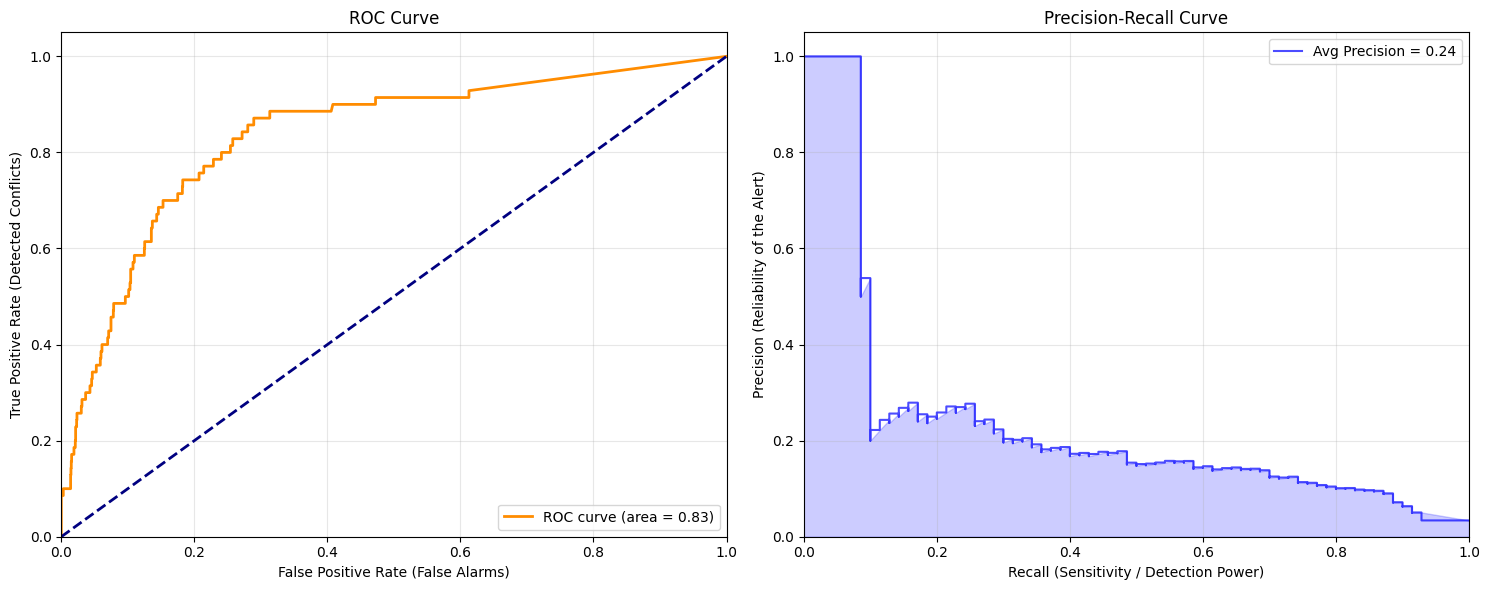

In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: ROC Curve ---
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (False Alarms)')
ax1.set_ylabel('True Positive Rate (Detected Conflicts)')
ax1.set_title('ROC Curve')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# --- Plot 2: Precision-Recall Curve ---
# This is the most important plot for imbalanced data!
precision, recall, _ = precision_recall_curve(all_y_true, all_y_prob)
avg_precision = average_precision_score(all_y_true, all_y_prob)

ax2.step(recall, precision, color='b', alpha=0.7, where='post', label=f'Avg Precision = {avg_precision:.2f}')
ax2.fill_between(recall, precision, alpha=0.2, color='b')
ax2.set_xlabel('Recall (Sensitivity / Detection Power)')
ax2.set_ylabel('Precision (Reliability of the Alert)')
ax2.set_ylim([0.0, 1.05])
ax2.set_xlim([0.0, 1.0])
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()